# Crimes violentos por 100 mil habitantes: Uberlândia e outras cidades de Minas

Números absolutos de criminalidade enganam: cidades maiores tendem a ter mais registros. O jeito certo de comparar é por habitante. Aqui eu pego os registros de crimes violentos da SEJUSP-MG (2019 a 2025), divido pela população do Censo 2022 e comparo Uberlândia com Belo Horizonte, Contagem, Juiz de Fora e Uberaba.

Atenção: os números contam **registros**, não vítimas nem processos. Um mesmo fato pode gerar mais de um registro, e a grafia das naturezas muda um pouco entre os anos (normalizei antes de somar).

## Preparando os dados

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

df = pd.read_csv("dados/crimes_cidades.csv")
df.head(10)

,municipio,ano,populacao_2022,crimes_violentos,homicidios,cv_por_100mil,hom_por_100mil
0,Uberlândia,2019,713224,3357,57,470.7,7.99
1,Uberlândia,2020,713224,1934,31,271.2,4.35
2,Uberlândia,2021,713224,1455,26,204.0,3.65
3,Uberlândia,2022,713224,1627,35,228.1,4.91
4,Uberlândia,2023,713224,1291,54,181.0,7.57
5,Uberlândia,2024,713224,1762,68,247.0,9.53
6,Uberlândia,2025,713224,1281,58,179.6,8.13
7,Uberaba,2019,337836,1679,23,497.0,6.81
8,Uberaba,2020,337836,1056,33,312.6,9.77
9,Uberaba,2021,337836,765,19,226.4,5.62


## Homicídios por 100 mil habitantes

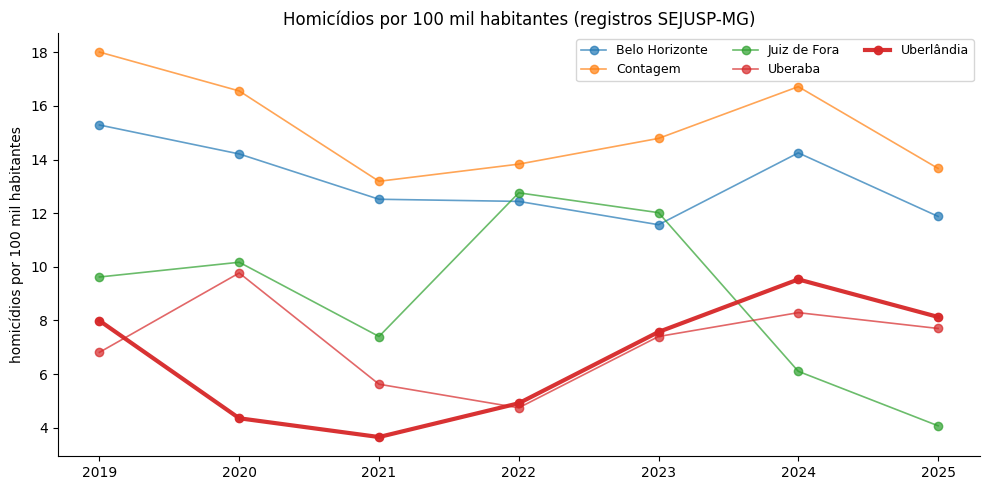

Uberlândia: {2019: 8.0, 2020: 4.3, 2021: 3.6, 2022: 4.9, 2023: 7.6, 2024: 9.5, 2025: 8.1}


In [2]:
fig, ax = plt.subplots()
for m, g in df.groupby("municipio"):
    lw = 3 if m == "Uberlândia" else 1.2
    cor = "#d62728" if m == "Uberlândia" else None
    ax.plot(g["ano"], g["hom_por_100mil"], marker="o", linewidth=lw, color=cor, label=m, alpha=0.95 if m=="Uberlândia" else 0.7)
ax.set_ylabel("homicídios por 100 mil habitantes")
ax.set_title("Homicídios por 100 mil habitantes (registros SEJUSP-MG)")
ax.legend(ncol=3, fontsize=9)
ax.set_xticks(range(2019, 2026))
plt.tight_layout()
plt.savefig("grafico_homicidios_100mil.png", dpi=150)
plt.show()

udi = df[df["municipio"]=="Uberlândia"].set_index("ano")["hom_por_100mil"]
print("Uberlândia:", {a: round(v,1) for a, v in udi.items()})

Uberlândia oscilou entre 3,6 (2021) e 9,5 (2024) homicídios por 100 mil habitantes no período, terminando 2025 em 8,1. Contagem e Belo Horizonte ficam consistentemente acima; Juiz de Fora fechou 2025 em 4,1, a menor taxa do grupo.

## Todos os crimes violentos por 100 mil

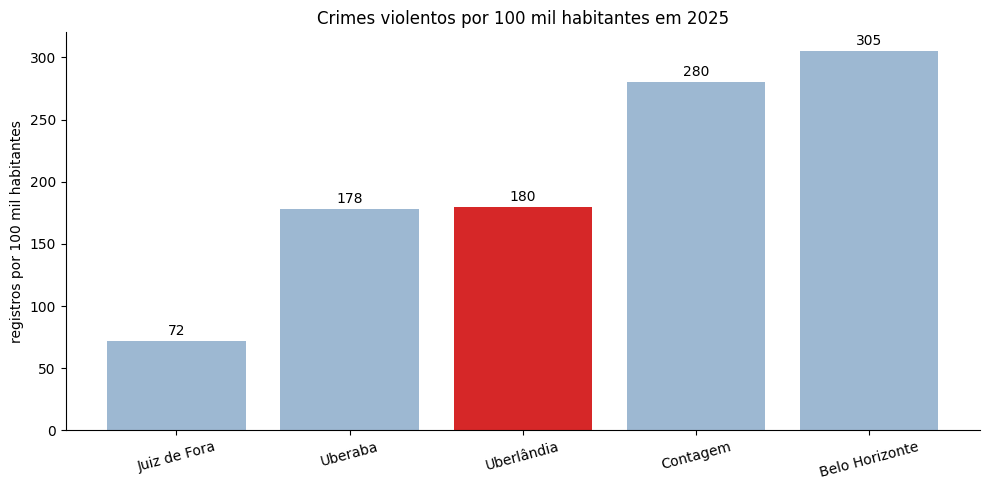

In [3]:
ult = df[df["ano"] == 2025].sort_values("cv_por_100mil")
cores = ["#d62728" if m == "Uberlândia" else "#9db8d2" for m in ult["municipio"]]
fig, ax = plt.subplots()
bars = ax.bar(ult["municipio"], ult["cv_por_100mil"], color=cores)
for b, v in zip(bars, ult["cv_por_100mil"]):
    ax.text(b.get_x() + b.get_width()/2, v + 5, f"{v:,.0f}".replace(",", "."), ha="center", fontsize=10)
ax.set_ylabel("registros por 100 mil habitantes")
ax.set_title("Crimes violentos por 100 mil habitantes em 2025")
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig("grafico_cv_2025.png", dpi=150)
plt.show()

Em 2025 Uberlândia teve 180 registros de crimes violentos por 100 mil habitantes, a menor taxa entre as cinco cidades.

## Ressalvas

- A base conta registros policiais, que dependem de a vítima registrar a ocorrência.
- Fontes oficiais divergem um pouco entre si: para homicídios de 2025 em Uberlândia, a SEJUSP registra 58, o Observatório da Segurança Pública aponta 59 e um levantamento do Ministério da Justiça chegou a 66. Usei a SEJUSP em tudo, para manter a série comparável entre as cidades.
- O recorte "crimes violentos" da SEJUSP inclui homicídio, roubo, estupro, lesão corporal e outros; a lista exata está no dicionário da base.
- População fixa do Censo 2022 para todos os anos: as taxas de 2025 usam a população de 2022, então tendem a estar levemente superestimadas nas cidades que cresceram.

## Fontes

- Registros: SEJUSP-MG, base de crimes violentos por município (https://dados.mg.gov.br/dataset/29d89d80-8aaf-438b-a80f-70bb64d10f6f).
- População: IBGE, Censo 2022, tabela SIDRA 4709.

Cruzamento feito por mim. O CSV em `dados/` tem tudo o que o gráfico usa.